In [1]:
from PIL import Image
import numpy as np
import cv2

# img1 = Image.open("/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/TPGS/data/iphone_processed/val_time/paper-windmill.npy")
img1 = np.array(Image.open("/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/TPGS/results/paper_windmill_test_1/renders/val_30218.png"))
img2 = np.array(Image.open("/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/TPGS/src/misc/2_00077.png"))
img3 = np.array(Image.open("/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/TPGS/src/misc/val_15218.png"))
gt = np.array(Image.open("/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/TPGS/data/iphone_processed/val_images/paper-windmill/00219.png"))
img1 = img1[480:, :360]
img3 = img3[480:, :360]
mask = np.array(Image.open("/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/TPGS/src/misc/image-2.png"))
Image.fromarray(img1).save("/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/TPGS/src/misc/2_00077_1.png")
Image.fromarray(img3).save("/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/TPGS/src/misc/2_00077_2.png")

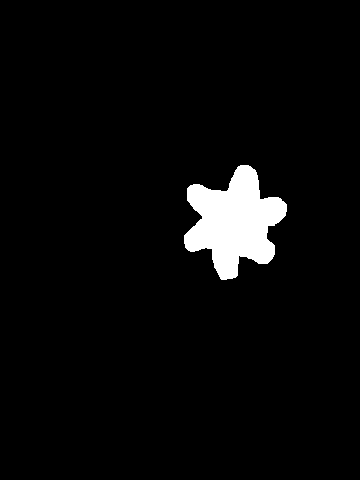

In [ ]:
mask = mask[..., -1] > 0 
mask = (mask * 255).astype(np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_DILATE, np.ones((5,5), dtype=np.uint8))
Image.fromarray(mask)

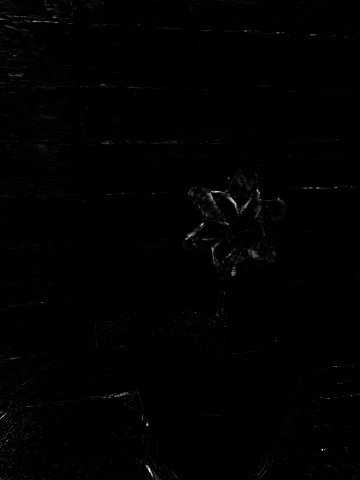

In [12]:
mse = np.mean((img1 / 255.0 - img2 / 255.0) ** 2, axis=-1)
mse_normalized = mse / np.max(mse)
mse
Image.fromarray((mse_normalized * 255).astype(np.uint8))

In [13]:
psnr_1 = -10 * np.log10(np.mean((img1 / 255.0 - gt / 255.0) ** 2))
psnr_2 = -10 * np.log10(np.mean((img2 / 255.0 - gt / 255.0) ** 2))
psnr_1, psnr_2

(21.990794712938122, 22.439382879583363)

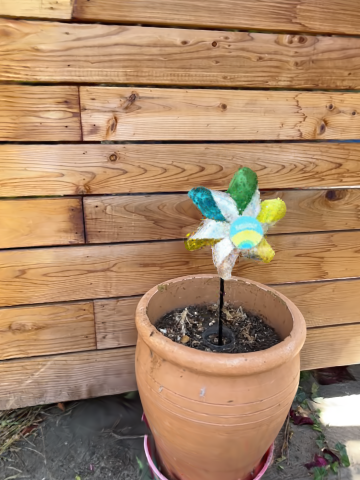

In [20]:
mask_bg = mask < 127.5
img1_with_img2_bg = img1.copy()
img1_with_img2_bg[mask_bg] = img2[mask_bg]
Image.fromarray(img1_with_img2_bg)

In [22]:
psnr_3 = -10 * np.log10(np.mean((img1_with_img2_bg / 255.0 - gt / 255.0) ** 2))
psnr_3

22.53811635143386